# Visualization Cookbook

This notebook collects reusable matplotlib recipes for inspecting outputs from the `spafe` Python extension: waveforms, filter banks, feature heatmaps, spectrograms, pitch tracks, cochleagrams, and a compact dashboard.

> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math
from collections.abc import Sequence

import matplotlib.pyplot as plt
import spafe

In [2]:
def sine_mix(seconds: float = 1.0, fs: int = 16_000) -> list[float]:
    samples = int(seconds * fs)
    return [
        0.65 * math.sin(2.0 * math.pi * 220.0 * n / fs)
        + 0.25 * math.sin(2.0 * math.pi * 440.0 * n / fs)
        + 0.10 * math.sin(2.0 * math.pi * 1760.0 * n / fs)
        for n in range(samples)
    ]


def plot_waveform(signal: Sequence[float], fs: int, seconds: float = 0.08) -> None:
    limit = min(len(signal), int(seconds * fs))
    times = [idx / fs for idx in range(limit)]
    fig, ax = plt.subplots(figsize=(12, 3.2), constrained_layout=True)
    ax.plot(times, signal[:limit], linewidth=1.0)
    ax.set_title("Waveform preview")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.25)
    plt.show()


def plot_heatmap(
    matrix: list[list[float]],
    title: str,
    xlabel: str,
    ylabel: str,
    cmap: str = "viridis",
) -> None:
    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.colorbar(image, ax=ax, shrink=0.85)
    plt.show()


def plot_filter_banks(
    fbanks: list[list[float]], freqs: list[float], title: str
) -> None:
    fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
    for row in fbanks:
        ax.plot(freqs, row, linewidth=0.9)
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Weight")
    ax.grid(True, alpha=0.25)
    plt.show()


def plot_pitch(
    times: list[float], pitches: list[float], dominant: list[float], dominant_hop: float
) -> None:
    dominant_times = [idx * dominant_hop for idx in range(len(dominant))]
    fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
    ax.plot(times, pitches, label="YIN pitch", linewidth=1.5)
    ax.plot(
        dominant_times, dominant, label="Dominant frequency", linewidth=1.0, alpha=0.75
    )
    ax.set_title("Pitch tracks")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

## Build a Signal and Feature Set

The cells below compute several outputs once, then reuse them in each plotting recipe.

In [3]:
fs = 16_000
signal = sine_mix(seconds=1.0, fs=fs)
opts = spafe.FeatureOptions(fs=fs, nfft=512, nfilts=32, num_ceps=13, win_hop=0.01)

mfcc = spafe.mfcc(signal, opts)
gfcc = spafe.gfcc(signal, opts)
mel_spec = spafe.mel_spectrogram(signal, opts)
erb_spec = spafe.erb_spectrogram(signal, opts)

filter_opts = spafe.FilterBankOptions(nfilts=32, nfft=512, fs=fs, high_freq=8_000.0)
mel_fbank, _ = spafe.mel_filter_banks(filter_opts)
gamma_fbank, _ = spafe.gammatone_filter_banks(filter_opts)
freqs = [idx * fs / filter_opts.nfft for idx in range(filter_opts.nfft // 2 + 1)]

pitches, harmonic_rates, argmins, pitch_times = spafe.compute_yin(signal, fs=fs)
dominant = spafe.get_dominant_frequencies(signal, fs=fs)

coch_opts = spafe.CochleagramOptions(
    signal_size=4096,
    sr=fs,
    env_sr=400,
    filter_n=16,
    low_lim=50.0,
    high_lim=6000.0,
    sample_factor=2,
    downsampling_window_size=129,
    compression="power",
)
coch = spafe.cochleagram(signal[:4096], coch_opts)

print(f"MFCC: {len(mfcc)} x {len(mfcc[0])}")
print(f"Mel spectrogram: {len(mel_spec.features)} x {len(mel_spec.features[0])}")
print(f"Cochleagram: {len(coch.cochleagram)} x {len(coch.cochleagram[0])}")

MFCC: 98 x 13
Mel spectrogram: 98 x 32
Cochleagram: 37 x 100


## Waveform Preview

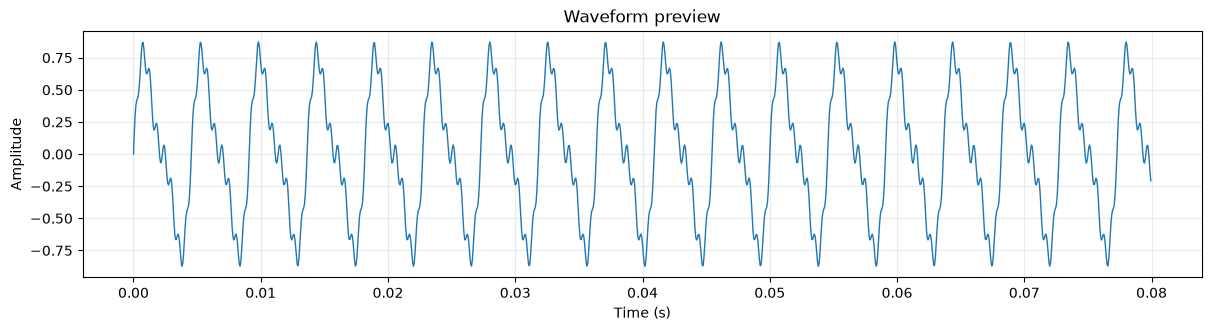

In [4]:
plot_waveform(signal, fs, seconds=0.08)

## Filter-Bank Overlays

Overlay plots are useful for inspecting spacing, scaling, and edge coverage.

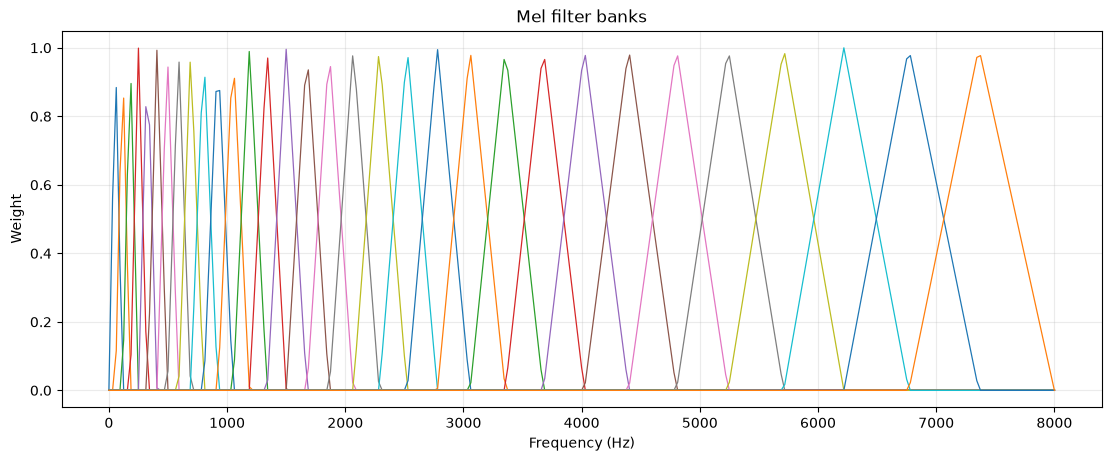

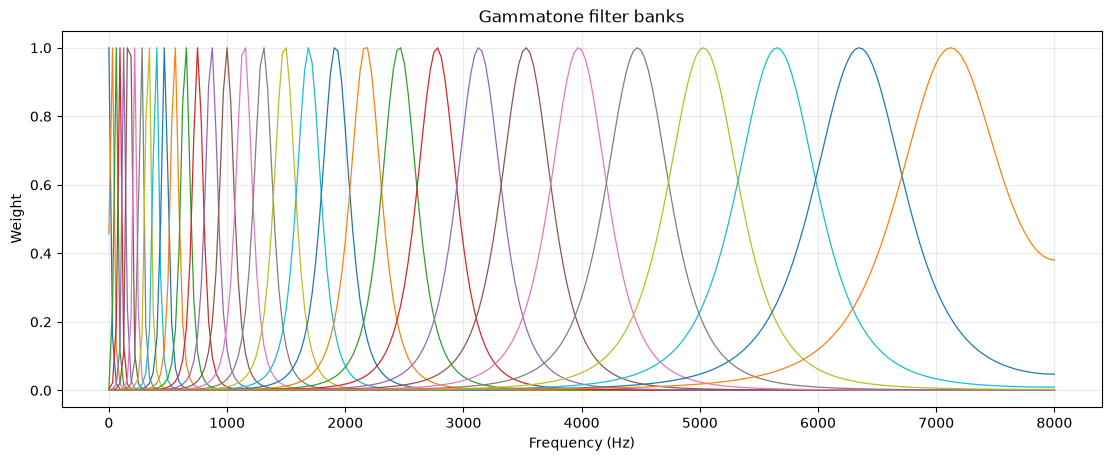

In [5]:
plot_filter_banks(mel_fbank, freqs, "Mel filter banks")
plot_filter_banks(gamma_fbank, freqs, "Gammatone filter banks")

## Feature Heatmaps

Use a fixed `origin="lower"` and label frame/coefficient axes so matrices from different extractors are easy to compare.

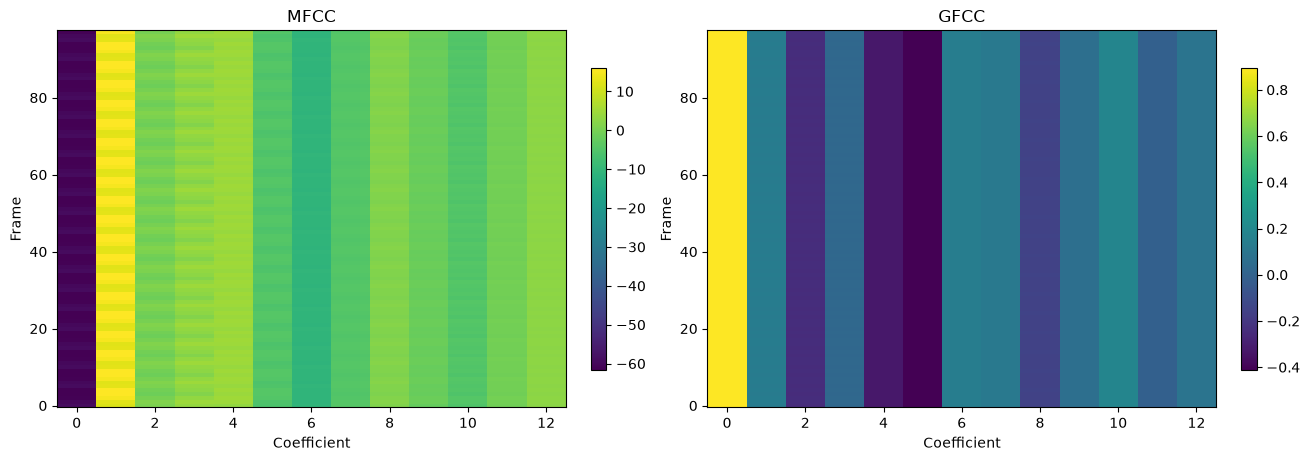

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, matrix, title in [(axes[0], mfcc, "MFCC"), (axes[1], gfcc, "GFCC")]:
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Frame")
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

## Spectrogram Panels

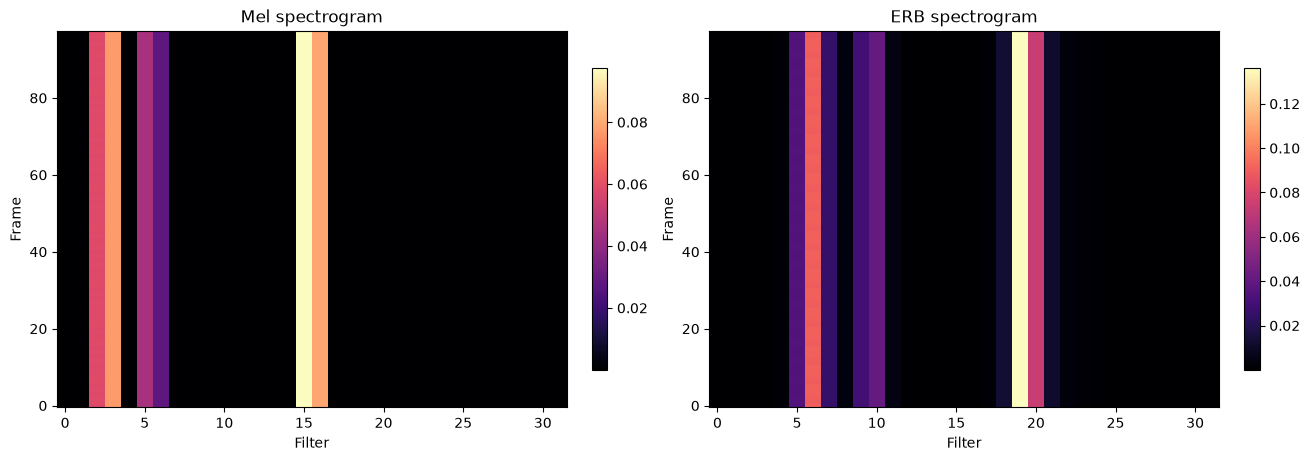

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, matrix, title in [
    (axes[0], mel_spec.features, "Mel spectrogram"),
    (axes[1], erb_spec.features, "ERB spectrogram"),
]:
    image = ax.imshow(matrix, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Filter")
    ax.set_ylabel("Frame")
    fig.colorbar(image, ax=ax, shrink=0.8)
plt.show()

## Pitch Tracks

Plotting YIN and dominant-bin estimates together is a quick way to see whether harmonic content is affecting the strongest spectral bin.

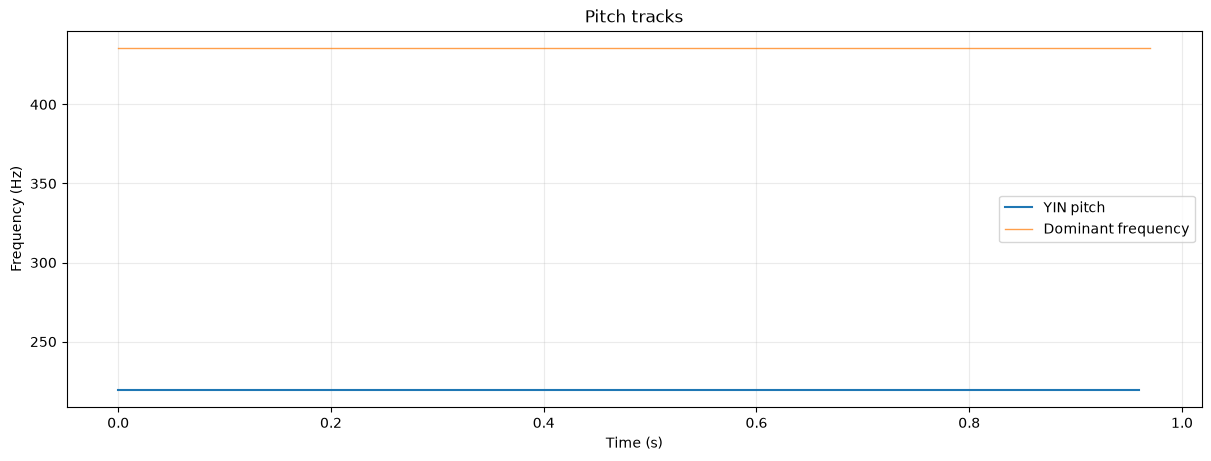

average voiced pitch: 219.178 Hz


In [8]:
plot_pitch(pitch_times, pitches, dominant, dominant_hop=0.010)
voiced = [pitch for pitch in pitches if pitch > 0.0]
print(f"average voiced pitch: {sum(voiced) / len(voiced):.3f} Hz")

## Cochleagram Heatmap

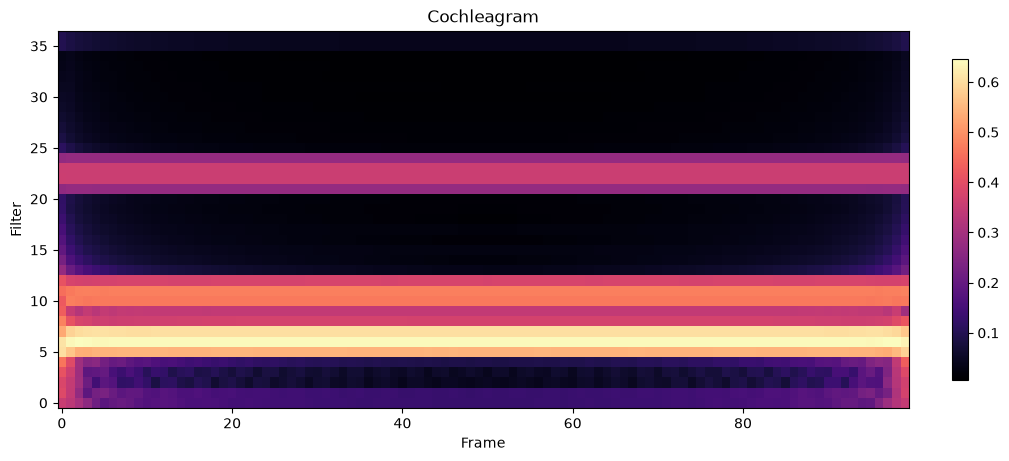

In [9]:
plot_heatmap(
    coch.cochleagram,
    title="Cochleagram",
    xlabel="Frame",
    ylabel="Filter",
    cmap="magma",
)

## Compact Dashboard

A dashboard is useful when tuning options because it keeps waveform, feature, pitch, and cochleagram views in one figure.

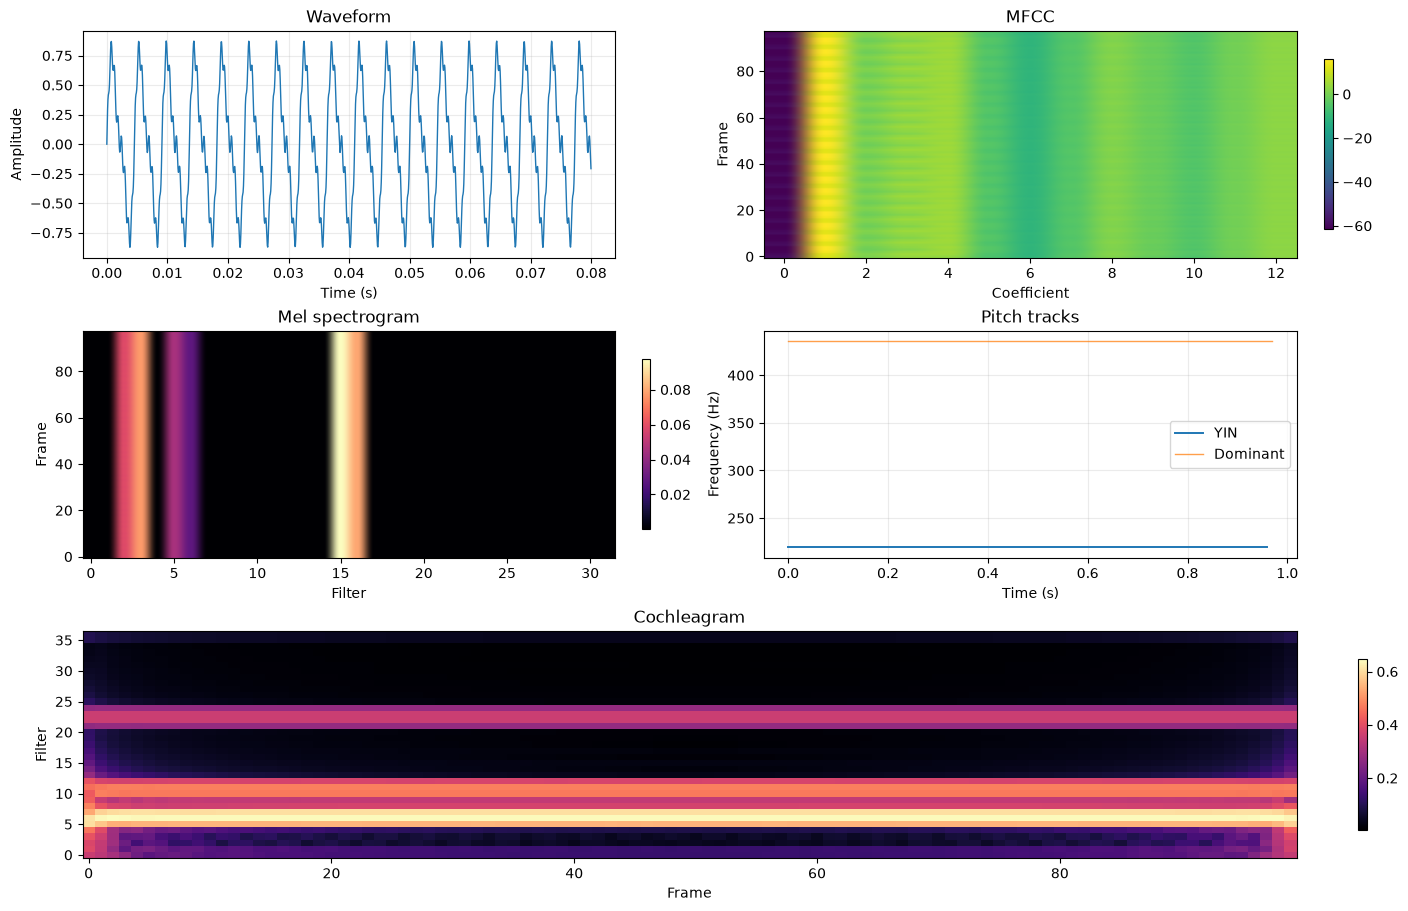

In [10]:
fig = plt.figure(figsize=(14, 9), constrained_layout=True)
grid = fig.add_gridspec(3, 2)

ax_wave = fig.add_subplot(grid[0, 0])
preview = signal[: int(0.08 * fs)]
ax_wave.plot([idx / fs for idx in range(len(preview))], preview, linewidth=1.0)
ax_wave.set_title("Waveform")
ax_wave.set_xlabel("Time (s)")
ax_wave.set_ylabel("Amplitude")
ax_wave.grid(True, alpha=0.25)

ax_mfcc = fig.add_subplot(grid[0, 1])
img = ax_mfcc.imshow(mfcc, aspect="auto", origin="lower", cmap="viridis")
ax_mfcc.set_title("MFCC")
ax_mfcc.set_xlabel("Coefficient")
ax_mfcc.set_ylabel("Frame")
fig.colorbar(img, ax=ax_mfcc, shrink=0.75)

ax_spec = fig.add_subplot(grid[1, 0])
img = ax_spec.imshow(mel_spec.features, aspect="auto", origin="lower", cmap="magma")
ax_spec.set_title("Mel spectrogram")
ax_spec.set_xlabel("Filter")
ax_spec.set_ylabel("Frame")
fig.colorbar(img, ax=ax_spec, shrink=0.75)

ax_pitch = fig.add_subplot(grid[1, 1])
ax_pitch.plot(pitch_times, pitches, label="YIN", linewidth=1.4)
ax_pitch.plot(
    [idx * 0.010 for idx in range(len(dominant))],
    dominant,
    label="Dominant",
    linewidth=1.0,
    alpha=0.75,
)
ax_pitch.set_title("Pitch tracks")
ax_pitch.set_xlabel("Time (s)")
ax_pitch.set_ylabel("Frequency (Hz)")
ax_pitch.grid(True, alpha=0.25)
ax_pitch.legend()

ax_coch = fig.add_subplot(grid[2, :])
img = ax_coch.imshow(coch.cochleagram, aspect="auto", origin="lower", cmap="magma")
ax_coch.set_title("Cochleagram")
ax_coch.set_xlabel("Frame")
ax_coch.set_ylabel("Filter")
fig.colorbar(img, ax=ax_coch, shrink=0.75)

plt.show()

## Plotting Tips

- Keep matrix orientation consistent: rows as frames or filters, columns as coefficients/bins.
- Use `aspect="auto"` for feature matrices so long signals remain readable.
- Use shared color maps for side-by-side comparisons.
- Add explicit units to axes: seconds, Hertz, filters, frames, coefficients.
- Build dashboards when tuning options so changes are visible across multiple outputs.